In [4]:
!pip install -q rasterio

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [6]:

# =====================================================
# Caminho da imagem
# =====================================================

raster_path = "/content/drive/MyDrive/Curso PDI com Python/L71221071_07120010720_DN.tif"

# =====================================================
# Leitura do raster
# =====================================================

with rasterio.open(raster_path) as src:

    profile = src.profile
    raster = src.read()


In [8]:


# =====================================================
# Reorganizando para matriz 2D
# =====================================================

X = raster.reshape(raster.shape[0], -1).T

# =====================================================
# Removendo pixels inválidos
# =====================================================

mask = np.all(np.isfinite(X), axis=1)

X_valid = X[mask]

# =====================================================
# Padronização
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_valid)

# =====================================================
# Teste de diferentes números de clusters
# =====================================================

n_components = range(1, 11)

bics = []

models = []

for n in n_components:

    print(f"Testando {n} clusters...")

    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(X_scaled)

    bic = gmm.bic(X_scaled)

    bics.append(bic)

    models.append(gmm)

# =====================================================
# Melhor modelo
# =====================================================

best_index = np.argmin(bics)

best_gmm = models[best_index]

best_n = n_components[best_index]

print(f"\nMelhor número de clusters: {best_n}")

# =====================================================
# Predição dos clusters
# =====================================================

labels = best_gmm.predict(X_scaled)

# =====================================================
# Reconstrução da imagem
# =====================================================

cluster_map = np.full(X.shape[0], -1)

cluster_map[mask] = labels

cluster_map = cluster_map.reshape(raster.shape[1], raster.shape[2])



Testando 1 clusters...
Testando 2 clusters...
Testando 3 clusters...
Testando 4 clusters...
Testando 5 clusters...
Testando 6 clusters...
Testando 7 clusters...
Testando 8 clusters...
Testando 9 clusters...
Testando 10 clusters...

Melhor número de clusters: 10


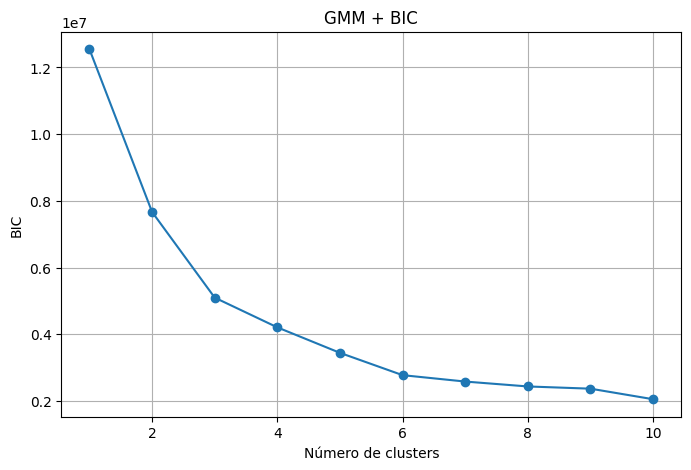

In [9]:
# =====================================================
# Plot BIC
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(n_components, bics, marker='o')

plt.xlabel("Número de clusters")
plt.ylabel("BIC")

plt.title("GMM + BIC")

plt.grid(True)

plt.show()

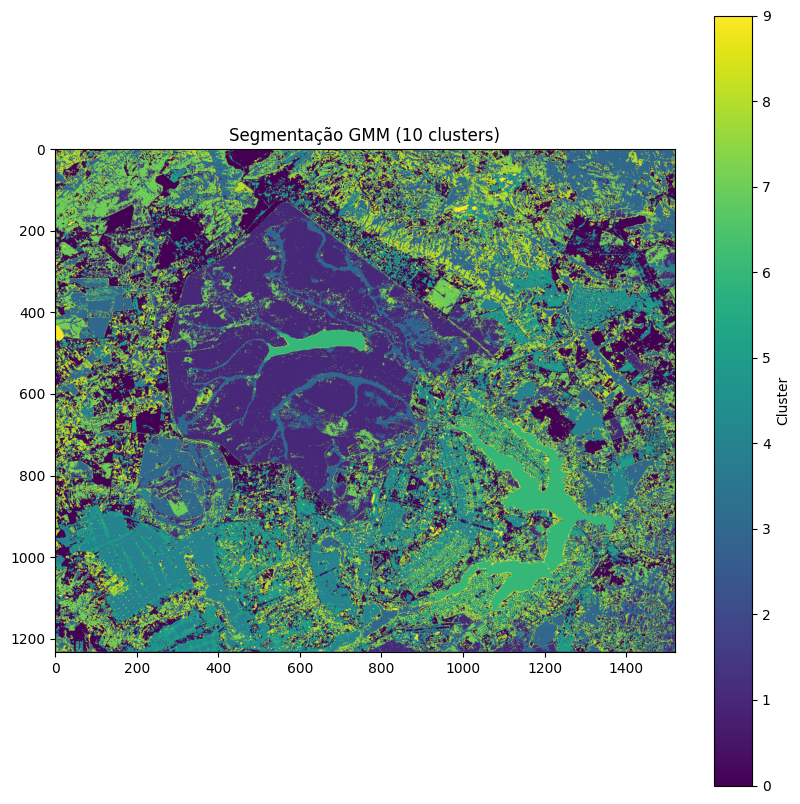

In [10]:
# =====================================================
# Plot resultado
# =====================================================

plt.figure(figsize=(10,10))

plt.imshow(cluster_map)

plt.title(f"Segmentação GMM ({best_n} clusters)")

plt.colorbar(label='Cluster')

plt.show()

In [ ]:
# =====================================================
# Salvando raster
# =====================================================

output_path = "/content/gmm_clusters.tif"

profile.update(
    count=1,
    dtype=rasterio.int32
)

with rasterio.open(output_path, 'w', **profile) as dst:

    dst.write(cluster_map.astype(rasterio.int32), 1)

print(f"\nRaster salvo em:\n{output_path}")